# LeetCode #137: Single Number II

https://leetcode.com/problems/single-number-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (Hash Map)** | $O(n)$ | $O(n)$ |
| **Bit-Count Mod 3** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (Hash Map)
Count occurrences of every number in a hash map, then return the one with count 1. $O(n)$ time but also $O(n)$ space for the map.

### Optimal: Bit-Count Mod 3 ★
For each of the 32 bit positions, count how many numbers have that bit set. Since every number appearing three times contributes a multiple of 3 to each bit count, taking `count % 3` for each position isolates only the single number's bits. Reconstruct the integer from those bits.

**Why this is better than Brute Force:** Achieves $O(1)$ space — no hash map — by exploiting the algebraic property that three identical numbers sum to $0 \pmod{3}$ at every bit position, leaving only the unique number's contribution.

**Constraints:**
* `1 <= nums.length <= 3 * 10^4`
* `-2^31 <= nums[i] <= 2^31 - 1`
* Every element appears exactly three times except for one

## Solutions

### C#

In [ ]:
public int SingleNumber(int[] nums) {
    int result = 0;
    // For each of the 32 bit positions, count how many numbers have that bit set
    for (int bit = 0; bit < 32; bit++) {
        int sum = 0;
        foreach (int num in nums) {
            // Accumulate the count of 1s at this bit position
            sum += (num >> bit) & 1;
        }
        // The single number's bit survives; triple-counts cancel out
        if (sum % 3 != 0) {
            result |= (1 << bit);
        }
    }
    return result;
}

### Python

In [ ]:
def singleNumber(self, nums: list[int]) -> int:
    result = 0
    # Check each of the 32 bit positions
    for bit in range(32):
        # Sum of all numbers' bits at this position mod 3 isolates the unique one
        total = sum((n >> bit) & 1 for n in nums) % 3
        if total:
            result |= total << bit
    # Restore sign for negative single numbers (two's complement 32-bit)
    if result >= (1 << 31):
        result -= (1 << 32)
    return result

### Go

In [ ]:
func singleNumber(nums []int) int {
    result := 0
    // Accumulate each bit position's count across all numbers
    for bit := 0; bit < 64; bit++ {
        sum := 0
        for _, n := range nums {
            // Count set bits at this position
            sum += (n >> bit) & 1
        }
        // Triple-appearing numbers cancel; leftover belongs to the unique element
        if sum%3 != 0 {
            result |= 1 << bit
        }
    }
    return result
}

### Rust

In [ ]:
pub fn single_number(nums: Vec<i32>) -> i32 {
    let mut result = 0i32;
    // Examine each of the 32 bit positions independently
    for bit in 0..32 {
        let sum: i32 = nums.iter().map(|&n| (n >> bit) & 1).sum();
        // Bits from the triply-appearing numbers sum to a multiple of 3
        if sum % 3 != 0 {
            result |= 1 << bit;
        }
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [2, 2, 3, 2]
Bit 0: counts = [0,0,1,0] → sum=1, 1%3=1 → result bit 0 = 1. Bit 1: counts = [1,1,1,1] → sum=4, 4%3=1 → result bit 1 = 1. Reconstructed: 11 in binary = **3**.

**2. Slightly Complex**
**Input:** nums = [0, 1, 0, 1, 0, 1, 99]
0 and 1 each appear three times. At every bit position their sum is divisible by 3. Only 99 (1100011 in binary) has leftover bits. Result = **99**.

**3. Edge Case: Time Factor**
**Input:** 30,000 elements where 9,999 distinct values each appear 3 times, plus one unique value
Every number is visited once per bit (32 passes over $n$ elements). Time $= 32n = O(n)$. This is the worst case for the scan but still linear.

**4. Edge Case: Space Factor**
**Input:** nums = [-2147483648, -2147483648, -2147483648, 1]
Negative numbers require correct 32-bit two's complement interpretation. The `% 3` filter still works across all 32 bits. Space = $O(1)$ regardless of input size.

**5. Almost-Impossible but Plausible**
**Input:** nums = [-1, -1, -1, -2147483648]
−1 in two's complement is all 1s (32 bits). Each bit's count = 3 + (bit from −2^31). Only bit 31 has count 3+1=4; 4%3=1 → result bit 31 set → reconstructs $-2{,}147{,}483{,}648$. Extreme negative boundary.

### Infographic

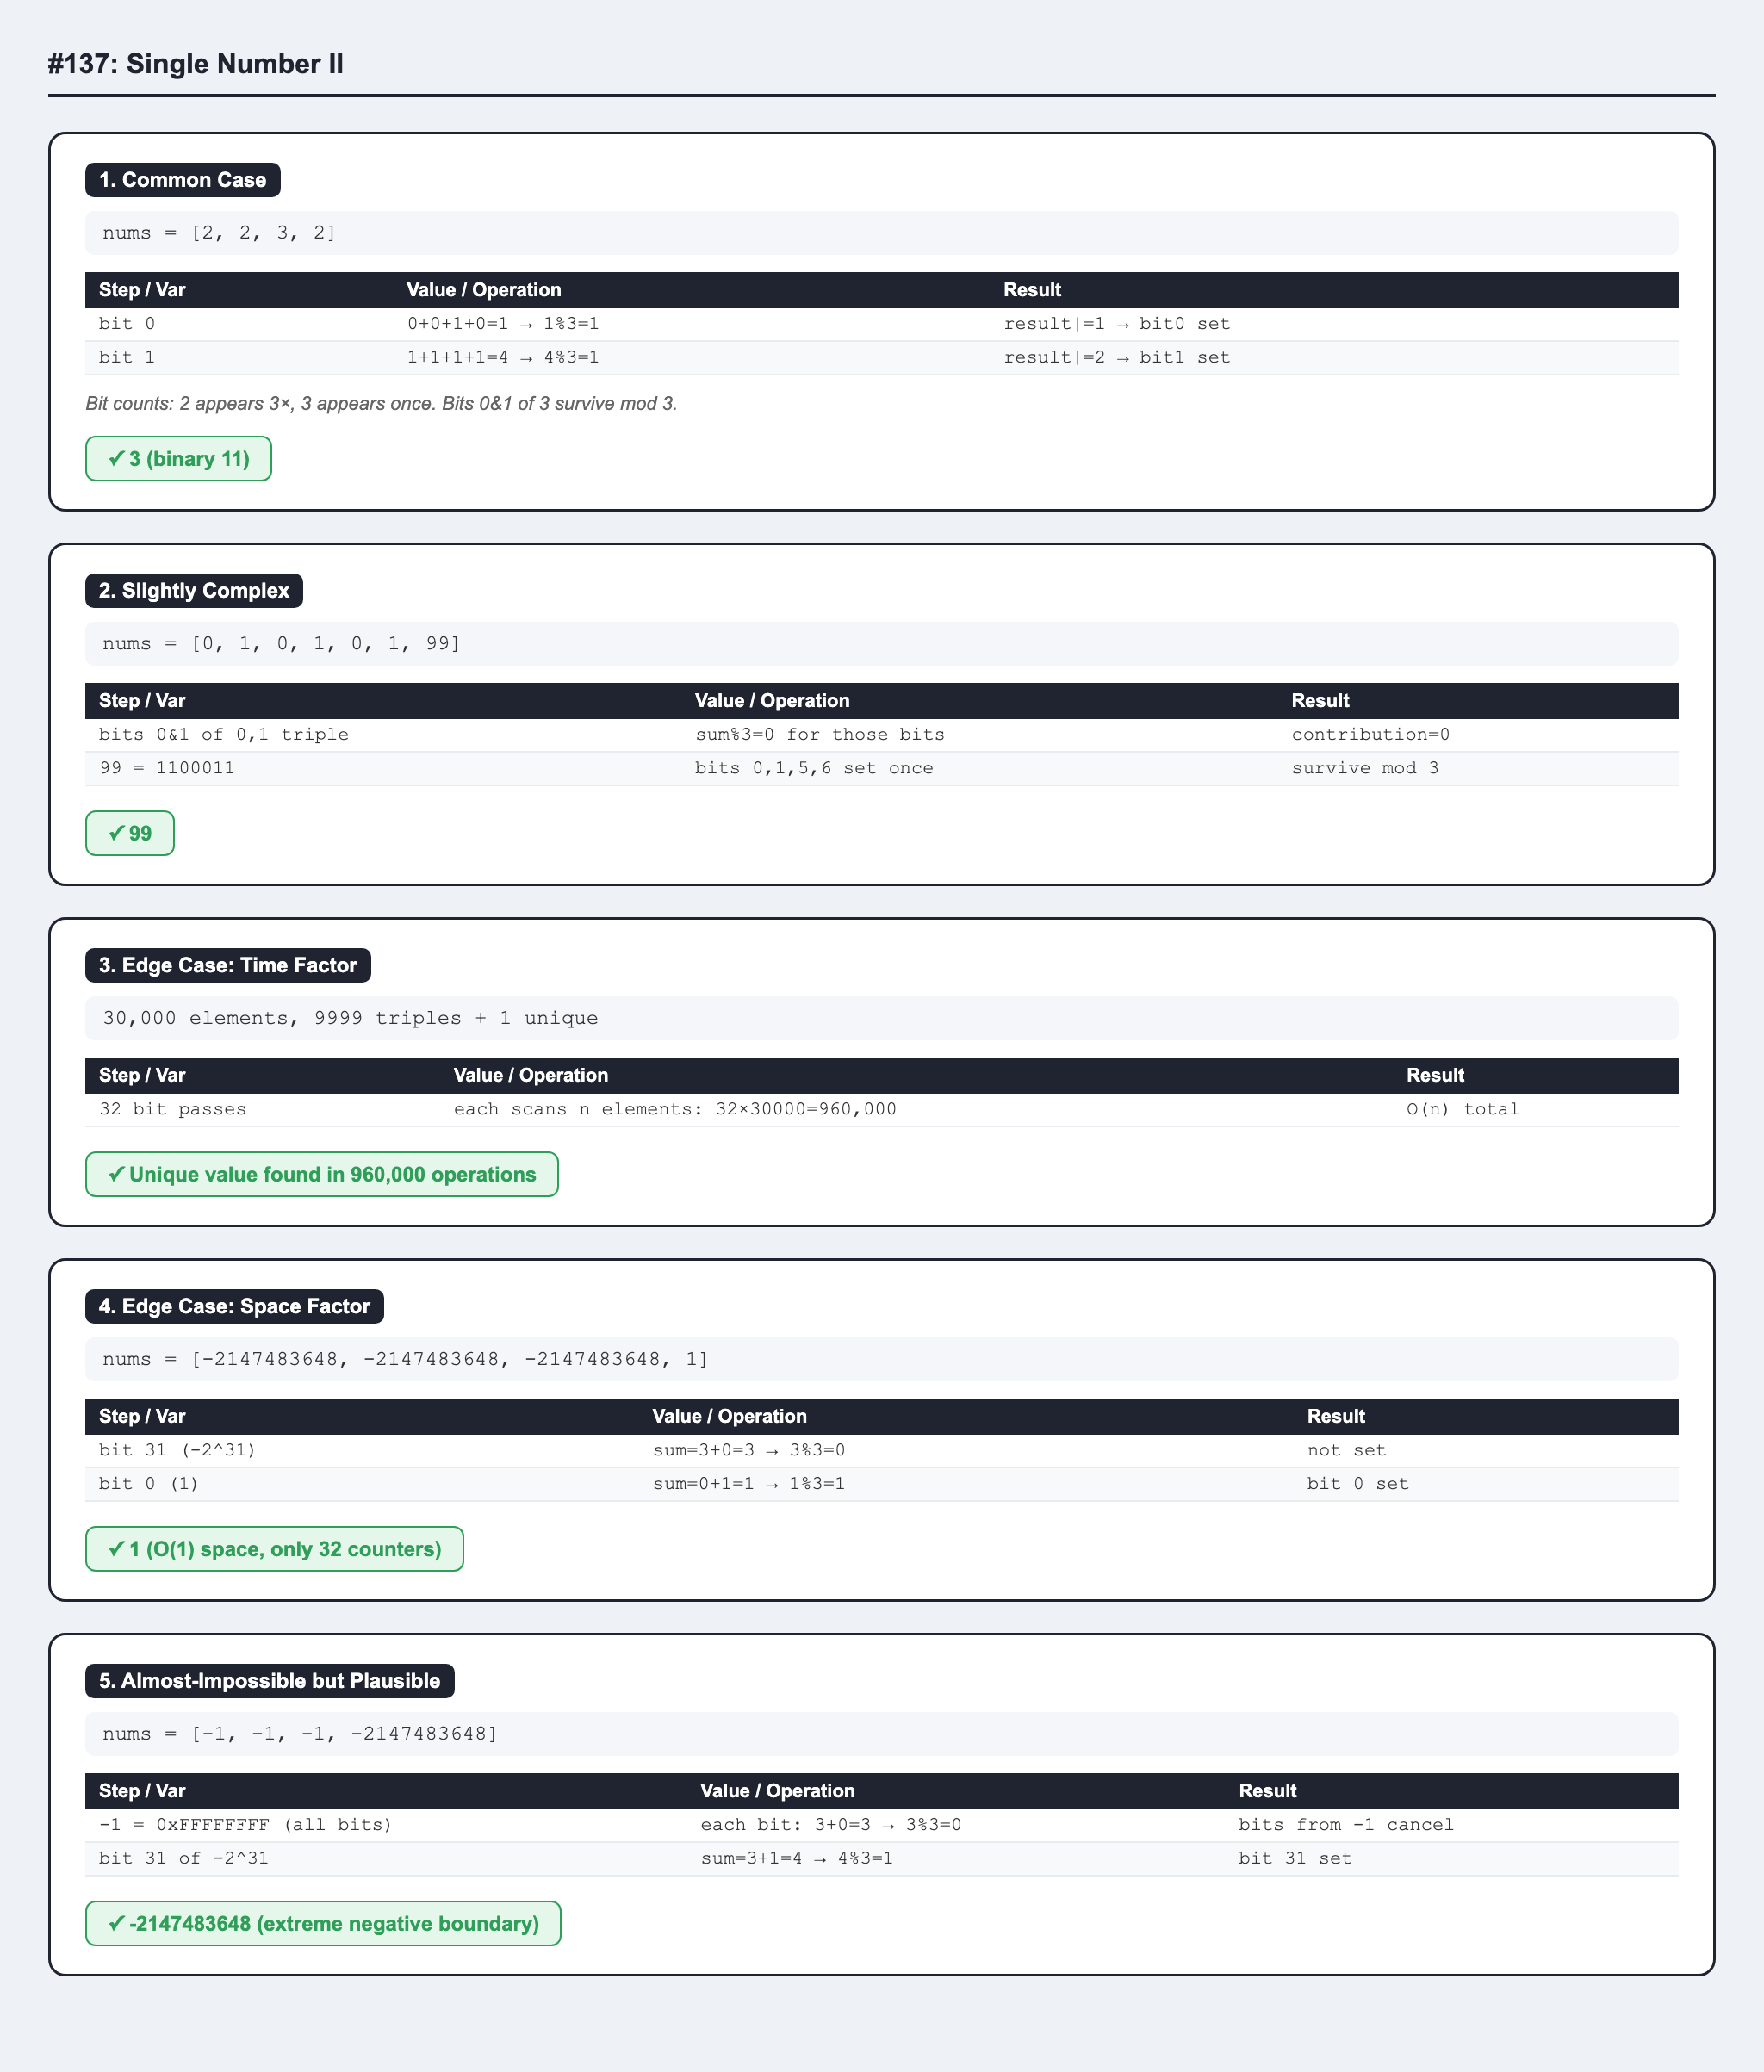